In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, beta

### MLE vs MAP: Understanding the Difference

| Concept | What it really does | Analogy |
|---------|---------------------|---------|
| **MLE** | Memorizes the data you give it. It does whatever it takes to make the training data look perfect. | A student who memorizes the exact test answers without understanding the subject. |
| **MAP (Regularization)** | Forgets the noise. It actively ignores small coincidences in the data and forces the model to stay boring, simple, and closer to zero. | A student who studies the general rules. They might get a few test questions wrong, but they actually understand the subject and can solve new problems. |


| MLE | MAP |
|-----|-----|
| 🎯 Fits training data perfectly | 🎯 Generalizes to new data |
| ❌ Overfits noise | ✅ Ignores noise |
| 📉 High variance | 📈 Low variance |
| 🤖 Memorizer | 🧠 Learner |

The Tradeoff

| | MLE | MAP |
|--|-----|-----|
| **On training data** | ✅ Perfect | ⚠️ Good enough |
| **On new data** | ❌ Poor (overfits) | ✅ Good (generalizes) |
| **Bias** | Low | Higher |
| **Variance** | High | Lower |

### MLE vs MAP: The Foundation of ML Loss Functions

| Method | Full Form | Definition |
|--------|-----------|------------|
| **MLE** | Maximum Likelihood Estimation | Finds parameters that maximize the probability of observing our data |
| **MAP** | Maximum A Posteriori | MLE + Prior beliefs about parameters |


**The Golden Rule:**

> Almost every ML loss function comes from **MLE** or **MAP**.

#### Examples

| Model | Loss Function | Derived From |
|-------|---------------|--------------|
| **Linear Regression** | MSE (Mean Squared Error) | MLE (Gaussian assumption) |
| **Logistic Regression** | Log Loss / Cross-Entropy | MLE (Bernoulli assumption) |
| **Ridge Regression** | MSE + L2 Penalty | MAP (Gaussian prior) |
| **Lasso Regression** | MSE + L1 Penalty | MAP (Laplace prior) |

### What is Posterior (Posteriori)?

**Posterior** (or *a posteriori*) represents your **updated belief** about something **after** seeing the data.

---

#### In Bayesian Terms

$$
\underbrace{P(\theta \mid X)}_{\text{Posterior}} = \frac{\overbrace{P(X \mid \theta)}^{\text{Likelihood}} \cdot \overbrace{P(\theta)}^{\text{Prior}}}{\underbrace{P(X)}_{\text{Evidence}}}
$$

| Term | Description |
|------|-------------|
| **Prior** | What you believed *before* seeing the data |
| **Likelihood** | How likely the data is, given your parameters |
| **Evidence** | The probability of the data (normalizing constant) |
| **Posterior** | What you believe *after* seeing the data |

---

#### Simple Analogy: Medical Test

| Step | Belief | Description |
|------|--------|-------------|
| **Prior** | 1% chance of disease | Before the test |
| **Likelihood** | Test positive given disease | How accurate is the test? |
| **Posterior** | 16% chance of disease | After positive test result |

**The posterior is your updated belief!**

---

#### In Machine Learning: MAP

**MAP (Maximum A Posteriori)** finds the parameters that maximize the posterior:

$$
\theta_{MAP} = \arg\max_\theta P(\theta \mid X) = \arg\max_\theta P(X \mid \theta) \cdot P(\theta)
$$

This is just **MLE + Prior**!

### MLE vs MAP in Practice

In **99% of standard Machine Learning libraries** (like `sklearn`), when you fit a **Linear Regression**, you are using **MLE**.

**BUT**, if you add a penalty like `alpha` (Ridge/Lasso), you are secretly using **MAP**.

---

#### Quick Reference

| Model | Method | What it means |
|-------|--------|---------------|
| **Linear Regression** | MLE | No prior — finds parameters that best fit the data |
| **Ridge / Lasso** | MAP | MLE + Prior (regularization penalty) |

#### sklearn Examples

```python
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# MLE (no prior)
lr = LinearRegression()           # MLE

# MAP (with prior)
ridge = Ridge(alpha=1.0)          # MAP (Gaussian prior)
lasso = Lasso(alpha=1.0)          # MAP (Laplace prior)

### MLE vs MAP: The Soup Analogy

**MLE (LinearRegression):** You taste the soup in front of you right now. You take one spoonful. It tastes a bit bland, so you add exactly 2 grams of salt to fix this specific spoonful. You trust that single taste completely.

**MAP (Ridge/Lasso):** You taste the soup, but you also remember the recipe book (your prior). The recipe book says "Always start with 0.5 grams of salt". You taste the bland spoonful, but you don't go all the way to 2 grams. Instead, you hedge your bets and add 1 gram. You partially trust the spoon, and partially trust the recipe book.


| Method | Trusts | Result |
|--------|--------|--------|
| **MLE** | Only the data (one spoonful) | Adds 2g salt — overfits to one taste |
| **MAP** | Data + Prior (recipe book) | Adds 1g salt — balances data and prior |

**MLE = Overconfident chef. MAP = Wise chef who follows the recipe!** 🍲


| Scenario | Choose |
|----------|--------|
| n_samples > n_features | MLE (LinearRegression) |
| n_features > n_samples | MAP (Ridge/Lasso) |
| Many useless features | MAP (Lasso) |
| Highly correlated features | MAP (Ridge) |
| Exploratory analysis | MLE |
| Better test performance | MAP |

- Use **MLE** when you have **big, clean data** and **trust the numbers**.

- Use **MAP (Regularization)** when your data is **small, messy**, or you want to **protect against overfitting**.

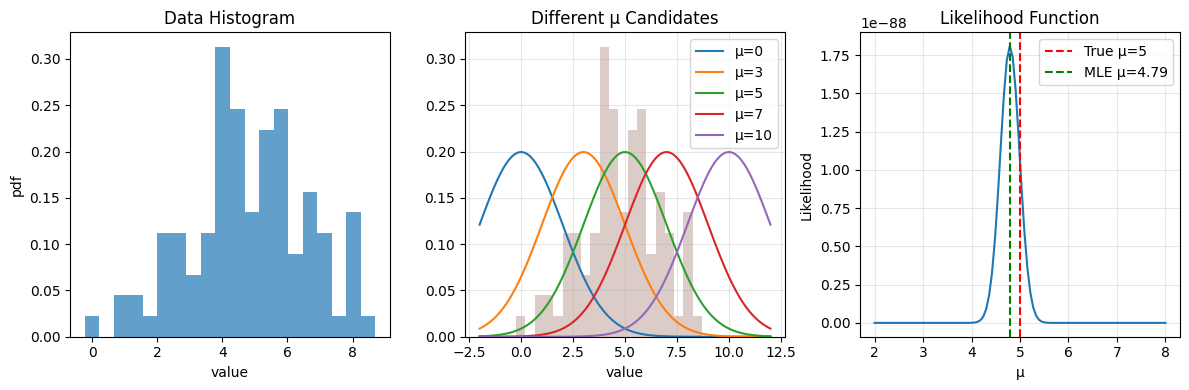

True μ: 5
MLE μ: 4.79
True σ: 2
MLE σ: 1.81


In [9]:
# Suppose we have data that we think comes from Normal distribution
np.random.seed(42)
true_mu, true_sigma = 5, 2
data = np.random.normal(true_mu, true_sigma, 100)

# What's the MLE for μ and σ?
# For Normal distribution:
# MLE(μ) = mean(data) = 5
# MLE(σ) = std(data) = 2

# Visualize different candidate distributions
plt.figure(figsize=(12, 4))

# Plot data histogram
plt.subplot(1, 3, 1)
plt.hist(data, bins=20, density=True, alpha=0.7)
plt.title('Data Histogram')
plt.xlabel('value')
plt.ylabel('pdf')

# Try different μ values
mu_candidates = [0, 3, 5, 7, 10]
plt.subplot(1, 3, 2)
for mu in mu_candidates:
    x = np.linspace(-true_sigma, 12, 100)
    plt.plot(x, norm.pdf(x, mu, 2), label=f'μ={mu}')
plt.hist(data, bins=20, density=True, alpha=0.3)
plt.title('Different μ Candidates')
plt.xlabel('value')
plt.legend()
plt.grid(alpha=0.3)

# Likelihood as function of μ
plt.subplot(1, 3, 3)
mu_range = np.linspace(true_sigma, 8, 100)
likelihoods = [np.prod(norm.pdf(data, mu, true_sigma)) for mu in mu_range]
plt.plot(mu_range, likelihoods)
plt.axvline(true_mu, color='r', linestyle='--', label=f'True μ={true_mu}')
plt.axvline(np.mean(data), color='g', linestyle='--', label=f'MLE μ={np.mean(data):.2f}')
plt.title('Likelihood Function')
plt.xlabel('μ')
plt.ylabel('Likelihood')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"True μ: {true_mu}")
print(f"MLE μ: {np.mean(data):.2f}")
print(f"True σ: {true_sigma}")
print(f"MLE σ: {np.std(data):.2f}")

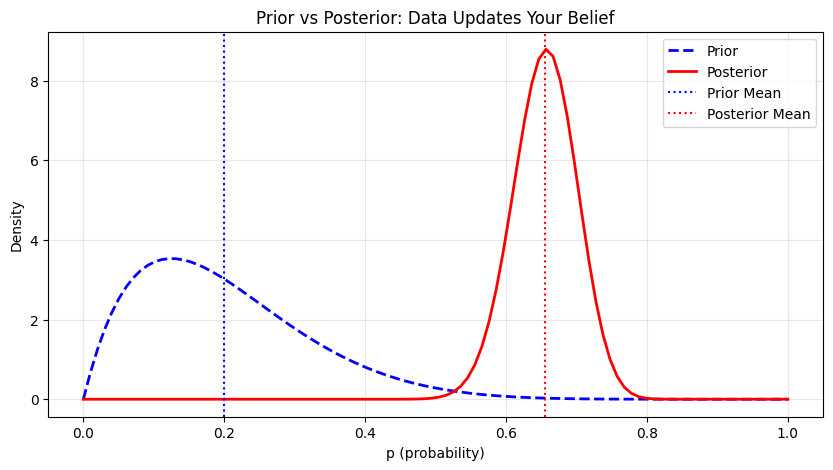

In [6]:
# Prior: Beta(2, 8) → belief that p ~ 20%
alpha_prior, beta_prior = 2, 8

# Data: 70 successes, 30 failures
successes, failures = 70, 30

# Posterior: Beta(2+70, 8+30) = Beta(72, 38)
alpha_post = alpha_prior + successes
beta_post = beta_prior + failures

# Plot
x = np.linspace(0, 1, 100)

plt.figure(figsize=(10, 5))
plt.plot(x, beta.pdf(x, alpha_prior, beta_prior), 'b--', label='Prior', linewidth=2)
plt.plot(x, beta.pdf(x, alpha_post, beta_post), 'r-', label='Posterior', linewidth=2)
plt.axvline(alpha_prior/(alpha_prior+beta_prior), color='b', linestyle=':', label='Prior Mean')
plt.axvline(alpha_post/(alpha_post+beta_post), color='r', linestyle=':', label='Posterior Mean')
plt.xlabel('p (probability)')
plt.ylabel('Density')
plt.title('Prior vs Posterior: Data Updates Your Belief')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [7]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Generate data
X, y = make_regression(n_samples=100, n_features=10, noise=0.5, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# MLE (No prior) = Ordinary Least Squares
from sklearn.linear_model import LinearRegression
mle_model = LinearRegression()
mle_model.fit(X_train, y_train)
mle_pred = mle_model.predict(X_test)

# MAP with Gaussian prior = Ridge (L2)
# λ controls the strength of the prior
ridge_models = {}
for alpha in [0.1, 1.0, 10.0]:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    ridge_models[alpha] = ridge

# MAP with Laplace prior = Lasso (L1)
lasso_models = {}
for alpha in [0.1, 1.0, 10.0]:
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train, y_train)
    lasso_models[alpha] = lasso

# Compare
print("MLE (No Regularization):")
print(f"  Test MSE: {mean_squared_error(y_test, mle_pred):.3f}")
print(f"  Coeff count: {np.sum(mle_model.coef_ != 0)}")

for alpha, model in ridge_models.items():
    pred = model.predict(X_test)
    print(f"Ridge (MAP, α={alpha}):")
    print(f"  Test MSE: {mean_squared_error(y_test, pred):.3f}")
    print(f"  Coeff L2 norm: {np.linalg.norm(model.coef_):.3f}")

for alpha, model in lasso_models.items():
    pred = model.predict(X_test)
    print(f"Lasso (MAP, α={alpha}):")
    print(f"  Test MSE: {mean_squared_error(y_test, pred):.3f}")
    print(f"  Coeff count: {np.sum(model.coef_ != 0)}")

MLE (No Regularization):
  Test MSE: 0.277
  Coeff count: 10
Ridge (MAP, α=0.1):
  Test MSE: 0.394
  Coeff L2 norm: 183.447
Ridge (MAP, α=1.0):
  Test MSE: 9.976
  Coeff L2 norm: 180.951
Ridge (MAP, α=10.0):
  Test MSE: 649.345
  Coeff L2 norm: 160.262
Lasso (MAP, α=0.1):
  Test MSE: 0.559
  Coeff count: 10
Lasso (MAP, α=1.0):
  Test MSE: 25.129
  Coeff count: 10
Lasso (MAP, α=10.0):
  Test MSE: 940.693
  Coeff count: 7


### What is Regularization Really Doing?

In plain English: **Regularization is a penalty that punishes your model for having large coefficients (weights).**

It forces the model to **share the credit** across all features rather than letting one or two features dominate.


### The Intuitive Analogy

Imagine you're a manager with **10 employees (features)** trying to predict sales.

**Without Regularization (MLE):** You find that Employee #1 is really good, so you fire the other 9 and give all the work to Employee #1. The model becomes entirely dependent on one person. If that person gets sick (noise in that feature), your predictions crash.

**With Regularization (MAP):** You say, *"I don't care if Employee #1 is slightly better. Everyone must contribute. I'll force you to spread the work evenly."* Now, if one employee gets sick, the other 9 can still do the job. The model is more **robust**.



| Without Regularization (MLE) | With Regularization (MAP) |
|------------------------------|---------------------------|
| Relies on 1-2 dominant features | Spreads importance across all features |
| Vulnerable to noise | Robust to noise |
| Overfits training data | Generalizes better |
| High variance | Lower variance |


Standard Linear Regression Loss (MLE)

$$
\text{Loss} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

**Goal:** Minimize this exactly.


Regularized Loss (MAP)

$$
\text{Loss} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \lambda \cdot \text{(Penalty on weights)}
$$

- The λ (lambda) is a dial that controls how much you care about keeping weights small vs. fitting the data.


**Goal:** Minimize prediction error AND keep weights small.